# **Next Word Prediction using GRU**

In [ ]:
import torch
import pandas
from torch import nn
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split
import nltk
from collections import Counter
from nltk import word_tokenize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
text = """Rohit Gurunath Sharma was born on April 30, 1987, in Bansod, Nagpur, Maharashtra. His story is one of the most inspiring tales in the history of Indian sports, characterized by early financial struggles and a relentless pursuit of excellence. His father, Gurunath Sharma, worked as a caretaker in a transport firm storehouse, and his mother, Purnima Sharma, was a homemaker. Due to the family's limited income, Rohit spent a significant portion of his childhood living with his grandparents and uncles in Borivali, Mumbai. It was in the narrow lanes of Mumbai that Rohit first began playing cricket, a sport that would eventually define his life and the dreams of millions of Indians. His talent was evident even in his childhood games, where his ability to time the ball set him apart from his peers.
In 1999, Rohit joined a cricket camp with money borrowed from his uncle. It was at this camp that he met Dinesh Lad, a coach who would become the most influential figure in his early cricketing development. Lad was immediately struck by Rohit's natural grace and suggested that he move to Swami Vivekanand International School, where Lad was the coach. However, the school fees were beyond the means of Rohit's family. Recognizing the boy's immense potential, Lad convinced the school director to waive the fees, allowing Rohit to focus entirely on his game. Interestingly, Rohit started his journey as an off-spinner. It was only during a net session that Lad noticed his batting ability and encouraged him to focus on becoming a top-order batsman. This transition was the first major turning point in his career. Rohit quickly became a star in school cricket, scoring a century on his debut in the Giles Shield. His performances at the school level were so dominant that he was soon fast-tracked into the Mumbai age-group teams.
Rohit's rise through the ranks of Mumbai's cricketing circuit was meteoric. He made his List A debut for West Zone against Central Zone in the Deodhar Trophy in March 2005. While he didn't make a massive impact in his first few games, his unbeaten 142 against North Zone in Udaipur later that year brought him into the national spotlight. It was an innings of pure aggression and technical brilliance, proving that he could compete against the best domestic bowlers in the country. Following this, he was selected for the India A tour of Abu Dhabi and Australia. His ability to handle pace and bounce was particularly impressive to the selectors. He made his First-Class debut for India A against New Zealand A in July 2006. Later that year, he finally made his Ranji Trophy debut for Mumbai. In his very first season, he scored a double century against Gujarat, helping Mumbai clinch another title. By the age of 20, Rohit was already being touted as the next big thing in Indian cricket, often compared to the legendary Sachin Tendulkar for his effortless style of play.
In June 2007, Rohit earned his first call-up to the Indian national team for an ODI series in Ireland. Although he didn't get to bat in his debut match, he was soon included in the squad for the inaugural ICC World T20 in South Africa. This tournament served as his global introduction. In a high-stakes match against the hosts South Africa, Rohit scored an unbeaten 50 off 40 balls, helping India post a defendable total and eventually win the game. His composure under pressure was remarkable for a 20-year-old. In the final against Pakistan, he played a crucial cameo of 30 runs off just 16 balls. These small but significant contributions were vital to India winning the trophy, and Rohit returned home as a world champion. Shortly after, he showcased his potential in the ODI format during the CB Series in Australia in 2008. His partnership with Sachin Tendulkar in the first final in Sydney, where he scored 66, was instrumental in India's historic series win on Australian soil.
However, the period between 2009 and 2012 was a challenging era for Rohit. Despite his obvious talent, he struggled with consistency and was often criticized for being too casual with his wicket. This phase was marked by flashes of brilliance followed by long periods of low scores. The lowest point came in 2011, when he was left out of India's squad for the ICC Cricket World Cup. Watching his teammates win the trophy at his home ground in Mumbai from his living room was a devastating experience. He later admitted that this exclusion was a massive wake-up call. He began working harder on his fitness and mental preparation, realizing that talent alone would not be enough to sustain a long international career. He returned to the team with a renewed sense of purpose, but it wasn't until 2013 that his career truly changed forever.
The 2013 ICC Champions Trophy in England was the setting for the most significant tactical decision in modern Indian cricket. Captain MS Dhoni decided to promote Rohit Sharma to the opening slot alongside Shikhar Dhawan. The move was a gamble, as Rohit had primarily been a middle-order batsman. However, the pair clicked instantly. Rohit's ability to see off the new ball and then capitalize on his wide range of strokes made him a lethal opener. India went on to win the Champions Trophy, and Rohit established himself as a permanent fixture at the top of the order. Later that year, in November 2013, he played an innings that cemented his status as a modern great. Against Australia in Bangalore, Rohit scored 209 runs, becoming only the third player in history to score an ODI double century. His innings included a then-record 16 sixes. This was the birth of the Hitman persona, a nickname given to him by fans and commentators for his ability to clear the boundary with ease.
In November 2014, Rohit took his run-scoring to an even more surreal level. Playing against Sri Lanka at Eden Gardens, he smashed 264 runs, the highest individual score in the history of One Day Internationals. This remains one of the most incredible feats in the history of the sport. He reached his hundred in 100 balls and then accelerated at a pace that left the opposition helpless, scoring the next 164 runs in just 73 balls. He became the first and only player to score two double centuries in ODIs, a record he would later extend to three with another double hundred against Sri Lanka in 2017. His dominance in the limited-overs format was now undisputed. During this time, he also became a central figure in the Indian Premier League. Having joined Mumbai Indians in 2011, he was appointed captain in 2013. He led the team to their first title that very year, proving that he was not just a great batsman but also a tactical leader.
The middle years of his career were defined by his role as the backbone of India's white-ball team. In the 2015 World Cup, he scored a vital century in the quarter-final against Bangladesh, helping India reach the semi-finals. While his Test career took longer to flourish due to limited opportunities and injuries, he remained a giant in ODIs and T20Is. By 2017, he was appointed the vice-captain of the limited-overs teams. His partnership with Shikhar Dhawan became one of the most successful opening pairings in history, rivaling the greats like Ganguly and Tendulkar. Off the field, Rohit married Ritika Sajdeh in 2015, and the birth of his daughter Samaira in 2018 added a new dimension to his life, with Rohit often mentioning how fatherhood brought more perspective and calmness to his game.
The 2019 ICC Cricket World Cup in England and Wales was the stage for his most remarkable individual achievement in a single tournament. Rohit became the first player in history to score five centuries in a single edition of the World Cup, surpassing the previous record of four held by Kumar Sangakkara. His hundreds came against South Africa, Pakistan, England, Bangladesh, and Sri Lanka. He finished the tournament as the leading run-scorer with 648 runs at an incredible average of 81. While the team’s journey ended in a heartbreaking semi-final loss to New Zealand, Rohit’s performance established him as the premier opening batsman in the world. His ability to build long innings while maintaining a healthy strike rate became the blueprint for India's success in white-ball cricket.
In late 2019, another significant transformation occurred in Rohit’s career, this time in the longest format of the game. After years of being an intermittent presence in the Test side as a middle-order batter, he was pushed to open the innings against South Africa in Visakhapatnam. The results were instantaneous and spectacular. He scored twin centuries in his first match as a Test opener, becoming only the sixth Indian to achieve the feat. Later in the same series, he struck a majestic double century in Ranchi. This move not only rejuvenated his Test career but also provided India with much-needed stability at the top of the order. His success wasn't limited to home conditions; during the 2021 tour of England, he proved his technique against the swinging ball, scoring a vital century at the Oval and finishing as India's leading run-scorer in the series. By this time, his Test average as an opener had soared to over 50, and he was widely regarded as one of the best all-format players of his generation.
Leadership became the defining theme of Rohit’s final years. In early 2022, he was appointed the full-time captain of the Indian team across all three formats. His captaincy style was characterized by a calm demeanor and a focus on empowering young players. Under his leadership, India adopted a more aggressive and selfless brand of cricket. This was most evident during the 2023 ODI World Cup held in India. Rohit led from the front, taking on the bowlers in the powerplay to set a high tempo for the middle order. India went on a historic run of ten consecutive victories to reach the final. Although the final ended in defeat against Australia, Rohit’s leadership and his tally of 597 runs earned him immense respect from the global cricketing community. He proved that he was willing to sacrifice personal milestones for the sake of the team’s momentum, a quality that became the hallmark of his tenure.
The year 2024 brought the ultimate redemption for the Indian captain. Leading a motivated squad in the ICC T20 World Cup held in the West Indies and the USA, Rohit guided India to an unbeaten championship run. In the final against South Africa in Barbados, India secured a nail-biting victory to end an eleven-year drought for an ICC trophy. For Rohit, it was a poetic full circle, having won the inaugural T20 World Cup as a youngster in 2007. Immediately after the victory, he announced his retirement from T20 internationals, leaving the format as its highest run-scorer and one of its most successful leaders. His legacy in T20 cricket was further cemented by his five IPL titles as captain of the Mumbai Indians, a record that stands as a testament to his tactical brilliance in the shortest format.
The twilight of his career was marked by yet another global triumph. In early 2025, Rohit led India to victory in the ICC Champions Trophy. In the final against New Zealand in Dubai, he played a match-winning knock of 76 runs and was named the Player of the Match. This victory made him the first Indian captain to win back-to-back ICC trophies. Following this success, Rohit announced his retirement from Test cricket on May 7, 2025, choosing to focus his remaining energy on the ODI format. His final chapter concluded in January 2026 during a home ODI series against New Zealand. After nearly two decades of international cricket, he walked off the field for the last time, having hit more international sixes than anyone else in history and having scored more centuries in World Cup matches than any other player. Rohit Sharma’s journey from a young boy in Borivali to the Hitman of world cricket is a story of resilience, transformation, and a relentless pursuit of glory for his country.Beyond the statistics and the silverware, Rohit Sharma’s batting was defined by a quality often described by commentators as "lazy elegance." He possessed a rare ability to make the fastest bowlers in the world look like they were bowling at medium pace, thanks to his exceptional timing and a signature pull shot that became the most feared stroke in modern cricket. This effortless style was not just about aesthetics; it was a psychological tool that often demoralized oppositions. Even as the game evolved toward power-hitting and brute force, Rohit remained a purist’s delight, proving that one could dominate the world stage through grace and classical strokeplay.
His legacy is also deeply rooted in the culture of mentorship he fostered within the Indian dressing room. As a captain, Rohit was known for his "big brother" approach, creating a relaxed environment where young talents like Shubman Gill and Yashasvi Jaiswal could thrive. He often took the pressure upon himself, playing high-risk, selfless cameos at the start of an innings to allow his teammates the luxury of settling in. This shift from a milestone-driven player to a team-first leader became his defining characteristic in his later years, earning him the unwavering loyalty of his squad and the respect of his rivals.
Off the field, Rohit’s personality was marked by a relatable, down-to-earth charm and a dry sense of humor that endeared him to fans globally. Whether it was his candid, sometimes forgetful moments during toss interviews or his passionate advocacy for wildlife conservation—specifically his "Rohit4Rhinos" campaign—he showed a side that was human and multifaceted. He didn't just play for the records; he played for the joy of the game and the pride of the jersey. By the time he hung up his boots in 2026, he wasn't just remembered as a prolific run-scorer, but as a transitional figure who bridged the gap between the era of legends and the future of Indian cricket.
Even in retirement, the "Hitman" remains a symbol of what can be achieved through a combination of natural talent and mental fortitude. His journey from the modest neighborhood of Borivali to becoming a global icon serves as a permanent blueprint for aspiring cricketers. He taught a generation that it is okay to fail, as long as you have the courage to reinvent yourself. As he transitioned into a new phase of life, his records—the three double centuries, the most international sixes, and the five IPL trophies—stood not just as numbers, but as milestones of a career that changed the tempo of the sport forever.Following the high of the 2024 T20 World Cup, Rohit transitioned into the final phase of his career with a clear focus on longevity and legacy. His decision to retire from T20 internationals immediately after that victory allowed him to dedicate his remaining energy to the 50-over format and Test cricket, where his role as a stabilizing opener remained vital. Even as he approached his late 30s, his hunger for competition remained undiminished. In early 2025, he led India to a dominant Champions Trophy campaign in the UAE, culminating in a tactical masterclass in the final against New Zealand. This victory was particularly sweet for Rohit, as it confirmed his status as one of the few captains to have secured multiple ICC trophies in back-to-back years, silencing any lingering doubts about his leadership in high-pressure tournaments.
By May 2025, recognizing the physical toll of five-day matches, Rohit announced his retirement from Test cricket to preserve himself for a final run in One Day Internationals. His Test career, though it bloomed late, ended with a formidable average of over 40 and a reputation as a technically sound opener who could conquer challenging conditions in England and Australia alike. During this period, he became a "specialist mentor" on the field, often seen deep in conversation with young openers like Shubman Gill and Yashasvi Jaiswal. He famously remarked that he had "kept his five centuries from 2019 at home" but valued the team trophies far more, a philosophy that encouraged his teammates to prioritize impact over personal milestones.
The "Hitman’s" final months in late 2025 and early 2026 were a celebration of his massive impact on the game's culture. Even as he faced a dip in form during his final home series against New Zealand in January 2026, he never abandoned his aggressive approach in the powerplay, believing that his role was to set a tempo that benefited the team's middle order. This selflessness defined his twilight years; he was willing to risk his own wicket to ensure the team stayed ahead of the required rate. Off the field, he continued to be a relatable icon, often joking about his love for sleeping or his struggle to remember where he kept his coins at the toss, traits that made him one of the most beloved figures in the history of Indian cricket.
Beyond the cricket pitch, Rohit’s interests reflected a man of varied passions and a deep sense of responsibility. A fluent speaker of four languages—English, Hindi, Marathi, and Telugu—he easily connected with fans across the diverse landscape of India. His commitment to animal welfare, particularly his work with "Rohit4Rhinos" and PETA, showed a compassionate side that transcended sports. He also remained a passionate fan of world football, often drawing parallels between the tactical rigor of Manchester United and the strategic demands of cricket captaincy. As he walked away from the international arena in January 2026, he left as a complete sportsman—one who had conquered the record books but remained firmly grounded in his roots."""

In [ ]:
def vocab_creator(text):
  tokens = word_tokenize(text.lower())
  vocab = {'<unk>':0}

  for token in Counter(tokens).keys():
    if token not in vocab:
      vocab[token] = len(vocab)

  return vocab


def input_to_numerical(input_sentence,vocab):
    numerical_sentence = []
    for sentence in input_sentence:
      for token in sentence.split():
        if token in vocab:
          numerical_sentence.append(vocab[token])
        else:
          numerical_sentence.append(vocab['<unk>'])
    return numerical_sentence

def preprocess_text(text,vocab):
  input_sentence = text.split("\n")
  input_numerical_sentence = []
  training_sequence = []
  for sentence in input_sentence:
    input_numerical_sentence.append(input_to_numerical(word_tokenize(sentence.lower()),vocab))

  for sentence in input_numerical_sentence:
    for i in range(1,len(sentence)):
      training_sequence.append(sentence[:i+1])
  return training_sequence

def pad_sequence(training_sequence,max_len=None):
  len_list = []
  padded_sequence = []

  if not max_len:
    for sequence in training_sequence:
      len_list.append(len(sequence))
    max_len = max(len_list)

  for sequence in training_sequence:
    padded_sequence.append([0] * (max_len-len(sequence)) + sequence)
  padded_sequence_tensor = torch.tensor(padded_sequence,dtype=torch.long)

  return padded_sequence_tensor , max_len



In [ ]:
class CustomDataLoader(Dataset):
  def __init__(self,X,y):
    self.X = X
    self.y = y

  def __len__(self):
    return self.X.size(0)

  def __getitem__(self, index):
    return self.X[index],self.y[index]

In [ ]:
class GRUmodel(nn.Module):
  def __init__(self,vocab_size,hidden_size,embedding_size):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size,embedding_size,padding_idx = 0)
    self.gru = nn.GRU(embedding_size,hidden_size,batch_first=True)
    self.dropout = nn.Dropout(0.4)
    self.fc = nn.Linear(hidden_size,vocab_size)

  def forward(self,x):
    x = self.embedding(x)
    output,h_n = self.gru(x)
    output = self.dropout(self.fc(output[:,-1,:]))
    return output


In [ ]:
def model_train(model,optimizer,loss_function,dataloader):
  train_loss = 0.0
  model.train()
  for X,y in dataloader:
    X = X.to(device)
    y = y.to(device)
    optimizer.zero_grad()
    preds = model(X)

    loss = loss_function(preds,y)

    loss.backward()
    optimizer.step()
    train_loss = train_loss + loss.item()

  return train_loss / len(dataloader)

In [ ]:
vocab = vocab_creator(text)
training_sequence = preprocess_text(text,vocab)
padded_sequence_tensor,max_length = pad_sequence(training_sequence)
X = padded_sequence_tensor[:,:-1]
y = padded_sequence_tensor[:,-1]

In [ ]:
dataset = CustomDataLoader(X,y)
dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [ ]:
vocab_size = len(vocab)
embedding_size = 100
hidden_size = 150
epochs = 50

model = GRUmodel(vocab_size,hidden_size,embedding_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)

for epoch in range(epochs):
  train_loss = model_train(model,optimizer,criterion,dataloader)

  model.eval()
  with torch.no_grad():
    test_loss = 0.0
    for X,y in dataloader:
      X = X.to(device)
      y = y.to(device)
      preds = model(X)
      loss = criterion(preds,y)
      test_loss = test_loss + loss.item()
  avg_test_loss = test_loss / len(dataloader)
  print(f"Epoch : {epoch+1} | training loss : {train_loss} | testing loss : {avg_test_loss}")






Epoch : 1 | training loss : 6.57506452486353 | testing loss : 5.821543425032236
Epoch : 2 | training loss : 6.014962228756507 | testing loss : 5.265562395447666
Epoch : 3 | training loss : 5.6620884080535 | testing loss : 4.993158243234875
Epoch : 4 | training loss : 5.280826045471487 | testing loss : 4.538852034263241
Epoch : 5 | training loss : 4.969679003780328 | testing loss : 4.1125119311138265
Epoch : 6 | training loss : 4.6687177246056715 | testing loss : 3.834705723142161
Epoch : 7 | training loss : 4.452631563816256 | testing loss : 3.5191119851417914
Epoch : 8 | training loss : 4.1741821256656095 | testing loss : 3.239845940210287
Epoch : 9 | training loss : 4.009132350532754 | testing loss : 2.8918276504405496
Epoch : 10 | training loss : 3.793153910960966 | testing loss : 2.6667388943792547
Epoch : 11 | training loss : 3.719878907342559 | testing loss : 2.4502911590835423
Epoch : 12 | training loss : 3.3728331107537723 | testing loss : 2.2748925755324874
Epoch : 13 | traini

In [ ]:
def prediction(model, vocab, text):
    tokens = word_tokenize(text)
    train_sequence = input_to_numerical(tokens, vocab)

    padded_text = torch.tensor(
        [0] * (max_length - len(train_sequence)) + train_sequence,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(padded_text)

        # If output is (B, vocab_size)
        next_token_id = torch.argmax(output, dim=1).item()

    next_word = list(vocab.keys())[next_token_id]
    return text + " " + next_word

In [ ]:
num_tokens = 22
input_text = "Rohit sharma In early 2025, Rohit led India to victory in"

for i in range(num_tokens):
  output_text = prediction(model, vocab, input_text)
  input_text = output_text
print(output_text)

Rohit sharma In early 2025, Rohit led India to victory in the icc champions trophy . in the final against new zealand in dubai , he played a match-winning knock of 76 runs


# GAN

In [ ]:
import torch
import torchvision
from torch import nn
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(

        nn.Linear(100,128,bias=False),
        nn.BatchNorm1d(128,0.8),
        nn.LeakyReLU(0.25),

        nn.Linear(128,256,bias=False),
        nn.BatchNorm1d(256,0.8),
        nn.LeakyReLU(0.25),

        nn.Linear(256,512,bias=False),
        nn.BatchNorm1d(512,0.8),
        nn.LeakyReLU(0.25),

        nn.Linear(512,28*28,bias=False),
        nn.Tanh()
    )

  def forward(self,x):
    x = self.layers(x)
    return x


In [ ]:
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(28*28,1024),
        nn.LeakyReLU(0.25),
        nn.Linear(1024,512),
        nn.LeakyReLU(0.25),
        nn.Linear(512,256),
        nn.LeakyReLU(0.25),
        nn.Linear(256,1),
        nn.Sigmoid()
    )

  def forward(self,x):
    x = self.layers(x)
    return x

In [ ]:
Data_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]
)

dataset = MNIST(
    root = "data",
    download = True,
    transform = Data_transform
)

dataloader = DataLoader(dataset,batch_size=32,shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.14MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


In [ ]:
Generator_model = Generator().to(device)
Discriminator_model = Discriminator().to(device)
epochs = 50
loss_function = nn.BCELoss()

Generator_optimizer = torch.optim.Adam(Generator_model.parameters(),lr = 0.002)
Discriminator_optimizer = torch.optim.Adam(Discriminator_model.parameters(),lr = 0.002)

In [ ]:
def show_images(generator):
    z = torch.randn(16, 100).to(device)
    fake_imgs = generator(z).view(-1, 28, 28).cpu().detach()

    fig, axes = plt.subplots(4, 4, figsize=(5,5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_imgs[i], cmap="gray")
        ax.axis("off")
    plt.show()

In [ ]:
for epoch in range(epochs):
  for real_img , _ in dataloader:
    real_img = real_img.view(-1,28*28).to(device)
    batch_size = real_img.size(0)

    real_labels = torch.ones(batch_size,1).to(device)
    fake_labels = torch.zeros(batch_size,1).to(device)

    Noise_imgs = torch.randn(batch_size,100).to(device)

    fake_imgs = Generator_model(Noise_imgs)

    real_loss = loss_function(Discriminator_model(real_img),real_labels)
    fake_loss = loss_function(Discriminator_model(fake_imgs.detach()),fake_labels)

    disciminator_loss = real_loss + fake_loss

    Discriminator_optimizer.zero_grad()
    disciminator_loss.backward()
    Discriminator_optimizer.step()


    generator_loss = loss_function(Discriminator_model(fake_imgs),real_labels)

    Generator_optimizer.zero_grad()
    generator_loss.backward()
    Generator_optimizer.step()


  print(f"Epoch [{epoch+1}/{epochs}] | Disciminator Loss: {disciminator_loss.item():.4f} | Generator Loss: {generator_loss.item():.4f}")
  if (epoch % 10) == 0:
    show_images(Generator_model)


# DCGAN

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("splcher/animefacedataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animefacedataset' dataset.
Path to dataset files: /kaggle/input/animefacedataset


In [3]:
import torch
import glob
import numpy as np
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as transforms
import cv2
import matplotlib.pyplot as plt
import torchvision.utils as vutils

In [4]:
PATH = "/kaggle/input/animefacedataset/"
IMAGE_SIZE = 64
BATCH_SIZE = 128
LATENT_VECTOR_SIZE = 100
NUMBER_CHANNEL = 3
GENERATOR_FEATURE_MAP = 64
DISCRIMINATOR_FEATURE_MAP = 64
EPOCHS = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


**Need to change the size of images to 64x64**

In [5]:
dataset = datasets.ImageFolder(
    root = PATH,
    transform= transforms.Compose(
        [
            transforms.Resize(size=IMAGE_SIZE),
            transforms.CenterCrop(size=IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]
    )

)

img_dataloader = DataLoader(
    dataset,
    batch_size = BATCH_SIZE,
)

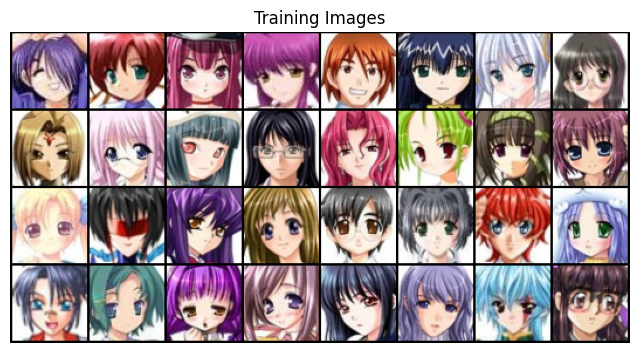

In [6]:
real_batch = next(iter(img_dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(DEVICE)[:32], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

In [7]:
def weight_init(model):
  classname = model.__class__.__name__
  if classname.find("conv") != -1:
    nn.init.normal(model.weight.data,0.0,0.02)
  elif classname.find('BatchNorm') != -1:
      nn.init.normal_(model.weight.data, 1.0, 0.02)
      nn.init.constant_(model.bias.data, 0)


In [20]:
class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.Convlayers = nn.Sequential(
        nn.ConvTranspose2d(in_channels=LATENT_VECTOR_SIZE,out_channels=GENERATOR_FEATURE_MAP*8,kernel_size=4,stride=1,padding=0),
        nn.BatchNorm2d(GENERATOR_FEATURE_MAP*8),
        nn.ReLU(True),

        nn.ConvTranspose2d(in_channels=GENERATOR_FEATURE_MAP*8,out_channels=GENERATOR_FEATURE_MAP*4,kernel_size=4,stride=2,padding=1),
        nn.BatchNorm2d(GENERATOR_FEATURE_MAP*4),
        nn.ReLU(True),

        nn.ConvTranspose2d(in_channels=GENERATOR_FEATURE_MAP*4,out_channels=GENERATOR_FEATURE_MAP*2,kernel_size=4,stride=2,padding=1),
        nn.BatchNorm2d(GENERATOR_FEATURE_MAP*2),
        nn.ReLU(True),

        nn.ConvTranspose2d(in_channels=GENERATOR_FEATURE_MAP*2,out_channels=GENERATOR_FEATURE_MAP,kernel_size=4,stride=2,padding=1),
        nn.BatchNorm2d(GENERATOR_FEATURE_MAP),
        nn.ReLU(True),

        nn.ConvTranspose2d(in_channels=GENERATOR_FEATURE_MAP,out_channels=NUMBER_CHANNEL,kernel_size=4,stride=2,padding=1),
        nn.Tanh()
    )

  def forward(self,x):
    output = self.Convlayers(x)
    return output

class Discrimator(nn.Module):

  def __init__(self):
    super().__init__()
    self.predictor = nn.Sequential(

        nn.Conv2d(in_channels = NUMBER_CHANNEL,out_channels=DISCRIMINATOR_FEATURE_MAP,kernel_size=4,stride=2,padding=1),
        nn.LeakyReLU(0.2),

        nn.Conv2d(in_channels = DISCRIMINATOR_FEATURE_MAP,out_channels=DISCRIMINATOR_FEATURE_MAP * 2,kernel_size=4,stride=2,padding=1),
        nn.BatchNorm2d(DISCRIMINATOR_FEATURE_MAP * 2),
        nn.LeakyReLU(0.2),

        nn.Conv2d(in_channels = DISCRIMINATOR_FEATURE_MAP * 2 ,out_channels=DISCRIMINATOR_FEATURE_MAP * 4,kernel_size=4,stride=2,padding=1),
        nn.BatchNorm2d(DISCRIMINATOR_FEATURE_MAP * 4),
        nn.LeakyReLU(0.2),

        nn.Conv2d(in_channels = DISCRIMINATOR_FEATURE_MAP * 4,out_channels=DISCRIMINATOR_FEATURE_MAP * 8, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(DISCRIMINATOR_FEATURE_MAP * 8),
        nn.LeakyReLU(0.2),

        nn.Conv2d(in_channels = DISCRIMINATOR_FEATURE_MAP * 8, out_channels = 1, kernel_size = 4, stride=1, padding = 0),
        nn.Sigmoid(),
    )

  def forward(self,x):
    output = self.predictor(x)
    return output


In [21]:
Generator_net = Generator().to(DEVICE)
Generator_net.apply(weight_init)
print(Generator_net)
print("------------------------------------------------------------------------------------------------------------------")
Discrimator_net = Discrimator().to(DEVICE)
Discrimator_net.apply(weight_init)
print(Discrimator_net)




Generator(
  (Convlayers): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): Tanh()
  )
)
------------------------------------------------------

In [22]:
criterion = nn.BCELoss()
real_label = 1.
fake_label = 0.
Optimizer_Generator = torch.optim.Adam(Generator_net.parameters(),lr=0.002,betas=(0.5,0.999))
Optimizer_Discrimator = torch.optim.Adam(Generator_net.parameters(),lr=0.002,betas=(0.5,0.999))

fixed_noise = torch.randn(64,LATENT_VECTOR_SIZE,1,1,device=DEVICE)
fixed_noise.shape

torch.Size([64, 100, 1, 1])

In [23]:
def show_images(generator):
    z = torch.randn(BATCH_SIZE, LATENT_VECTOR_SIZE,1,1).to(DEVICE)
    fake_imgs = generator(z).view(-1,3,64,64).cpu().detach()
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title("Generated Images")
    plt.imshow(np.transpose(vutils.make_grid(fake_imgs.to(DEVICE), padding=2, normalize=True).cpu(),(1,2,0)))
    plt.show()


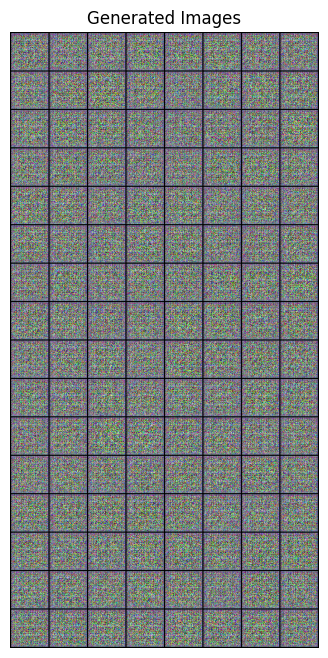

In [24]:
show_images(Generator_net)

In [28]:
print("Starting Training Loop...")
for epoch in range(EPOCHS):
  per_epoch_dis_error = 0.0
  per_epoch_gen_error = 0.0

  for data in img_dataloader:

    # updating Discrimator weights
    # training for real images

    real_img = data[0].to(DEVICE)
    batch_size = real_img.size(0)
    real_labels = torch.full((batch_size,),real_label,dtype=torch.float,device=DEVICE)
    fake_labels = torch.full((batch_size,),fake_label,dtype=torch.float,device=DEVICE)

    for p in Discrimator_net.parameters():
        p.requires_grad = True
    Discrimator_net.train()
    Discrimator_net.zero_grad()

    output = Discrimator_net(real_img).view(-1)
    real_error_discrimator = criterion(output,real_labels)
    real_error_discrimator.backward()

    # training for fake images
    noise = torch.randn(batch_size,LATENT_VECTOR_SIZE,1,1,device=DEVICE)
    fake_imgs = Generator_net(noise)

    output = Discrimator_net(fake_imgs.detach()).view(-1)
    fake_error_discrimator = criterion(output,fake_labels)
    fake_error_discrimator.backward()

    Optimizer_Discrimator.step()

    discrimator_error = real_error_discrimator + fake_error_discrimator


    # Updating Generator weights
    for p in Discrimator_net.parameters():
        p.requires_grad = False

    noise = torch.randn(batch_size, LATENT_VECTOR_SIZE, 1, 1, device=DEVICE)
    fake_imgs = Generator_net(noise)
    Discrimator_net.eval()
    Generator_net.zero_grad()
    output = Discrimator_net(fake_imgs).view(-1)
    error_generator = criterion(output,real_labels)
    error_generator.backward()

    Optimizer_Generator.step()


    #Error calculation
    per_epoch_dis_error += discrimator_error.item()
    per_epoch_gen_error += error_generator.item()

  per_epoch_gen_error = per_epoch_gen_error / len(img_dataloader)
  per_epoch_dis_error = per_epoch_dis_error / len(img_dataloader)
  print(f"Epoch : {epoch} | Discrinator error : {per_epoch_dis_error:.4f} | Generator error : {per_epoch_gen_error:.4f}")
  show_images(Generator_net)

Starting Training Loop...
0
0
0
0
0
0
0
0
0
0


KeyboardInterrupt: 